In [1]:
import numpy as np 
import matplotlib.pyplot as plt


In [2]:
X = np.linspace(-5.0, 5.0, 100)
y = np.sqrt(10**2 - X**2)
y = np.hstack([y, -y])
X = np.hstack([X, -X])

In [3]:
print(np.sqrt([1,2,3,4,5]))

[1.         1.41421356 1.73205081 2.         2.23606798]


In [4]:
X1 = np.linspace(-5.0, 5.0, 100)
y1 = np.sqrt(5**2 - X1**2)
y1 = np.hstack([y1, -y1])
X1 = np.hstack([X1, -X1])

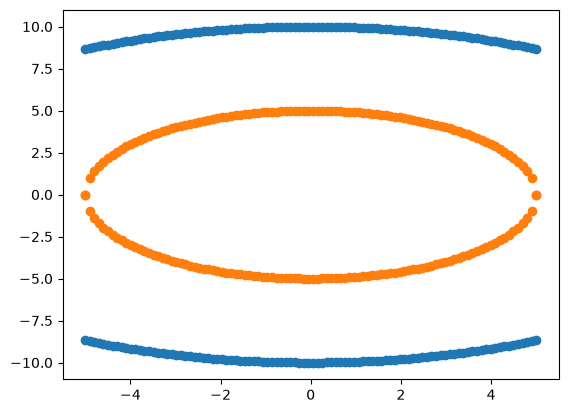

In [5]:
plt.Figure(figsize=(20,20))
plt.scatter(X, y)
plt.scatter(X1, y1)

In [6]:
import pandas as pd
df1 = pd.DataFrame(np.vstack([y,X]).T, columns= ['X1', 'X2'])
df1['Y'] = 0
df2 = pd.DataFrame(np.vstack([y1, X1]).T, columns=['X1', 'X2'])
df2['Y'] = 1
df = pd.concat([df1, df2], ignore_index=True)

In [7]:
print(df.head(),df.tail(), sep=f'\n hi there \n')

         X1       X2  Y
0  8.660254 -5.00000  0
1  8.717792 -4.89899  0
2  8.773790 -4.79798  0
3  8.828277 -4.69697  0
4  8.881281 -4.59596  0
 hi there 
           X1       X2  Y
395 -1.969049 -4.59596  1
396 -1.714198 -4.69697  1
397 -1.406908 -4.79798  1
398 -0.999949 -4.89899  1
399 -0.000000 -5.00000  1


In [8]:
X = df.iloc[:, :-1]  
y = df.iloc[:, -1]

In [9]:
X, y

(           X1       X2
 0    8.660254 -5.00000
 1    8.717792 -4.89899
 2    8.773790 -4.79798
 3    8.828277 -4.69697
 4    8.881281 -4.59596
 ..        ...      ...
 395 -1.969049 -4.59596
 396 -1.714198 -4.69697
 397 -1.406908 -4.79798
 398 -0.999949 -4.89899
 399 -0.000000 -5.00000
 
 [400 rows x 2 columns],
 0      0
 1      0
 2      0
 3      0
 4      0
       ..
 395    1
 396    1
 397    1
 398    1
 399    1
 Name: Y, Length: 400, dtype: int64)

In [10]:
## Split the dataset into train and test
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)

### Polynomial Kernel
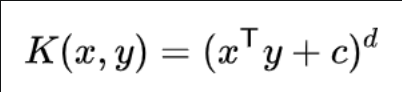

In [11]:
# We need to find components for the Polynomical Kernel
#X1,X2,X1_square,X2_square,X1*X2
df['X1_Square']= df['X1']**2
df['X2_Square']= df['X2']**2
df['X1*X2'] = (df['X1'] *df['X2'])
df.head()

,X1,X2,Y,X1_Square,X2_Square,X1*X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [12]:
### Independent and Dependent features
X = df[['X1','X2','X1_Square','X2_Square','X1*X2']]
y = df['Y']

In [13]:

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = 0.25, 
                                                    random_state = 0)


In [14]:
import plotly.express as px

fig = px.scatter_3d(df, x='X1', y='X2', z='X1*X2',
              color='Y')
fig.show()

In [15]:

fig = px.scatter_3d(df, x='X1_Square', y='X1_Square', z='X1*X2',
              color='Y')
fig.show()

In [16]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [17]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel="poly")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [18]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel="rbf")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [19]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel="sigmoid")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)

1.0